# 04 - Results: Classic tree models

### Setup configuration

In [1]:
import time

import pandas as pd
import numpy as np
import plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from torch_geometric.data import Data

from src.data.load_raw import load_raw_data
from src.data.preprocess import (
    extract_xy,
    merge_features_and_labels,
    standardize_splits,
)
from src.data.split import split_labeled_transactions
from src.evaluation.metrics import calculate_binary_metrics
from src.evaluation.threshold import find_best_f1_threshold
from src.models.classic import (
    build_dummy_classifier,
    build_logistic_regression,
    build_random_forest,
    build_xgboost,
)

from src.models.mlp import build_mlp
from src.models.gcn import build_gcn

features_df, classes_df, edges_df = load_raw_data()

transactions_df = merge_features_and_labels(
    features_df,
    classes_df,
)

splits = split_labeled_transactions(transactions_df)

C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Setup 'local' data split

In [2]:
x_train, y_train = extract_xy(
    splits.train,
    feature_set="local",
)

x_validation, y_validation = extract_xy(
    splits.validation,
    feature_set="local",
)

x_test, y_test = extract_xy(
    splits.test,
    feature_set="local",
)

(
    scaler,
    x_train_scaled,
    x_validation_scaled,
    x_test_scaled,
) = standardize_splits(
    x_train,
    x_validation,
    x_test,
)

### Setup 'all' data split

In [3]:
x_all_train, y_all_train = extract_xy(
    splits.train,
    feature_set="all",
)

x_all_validation, y_all_validation = extract_xy(
    splits.validation,
    feature_set="all",
)

x_all_test, y_all_test = extract_xy(
    splits.test,
    feature_set="all",
)

(
    all_scaler,
    x_all_train_scaled,
    x_all_validation_scaled,
    x_all_test_scaled,
) = standardize_splits(
    x_all_train,
    x_all_validation,
    x_all_test,
)

In [4]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

In [5]:
results = []

def run_experiment(model_name, model, feature_set, x_train, y_train, x_validation, y_validation, x_test, y_test):
    start_time = time.perf_counter()

    model.fit(x_train, y_train)

    training_time = time.perf_counter() - start_time

    validation_scores = model.predict_proba(x_validation)[:, 1]

    threshold = find_best_f1_threshold(y_validation, validation_scores)

    test_scores = model.predict_proba(x_test)[:, 1]

    metrics = calculate_binary_metrics(y_test, test_scores, threshold=threshold)

    metrics.update(
        {
            "model": model_name,
            "feature_set": feature_set,
            "training_time_seconds": training_time,
        }
    )

    results.append(metrics)

    return model, metrics

In [6]:
def run_gcn_experiment(model_name, model, data, train_mask, val_mask, test_mask, epochs=1000, lr=0.001):
    start_time = time.perf_counter()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    pos_weight = torch.tensor([0.7 / 0.3]).to(model.device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()

        out, _ = model(data.x, data.edge_index)

        loss = criterion(out[train_mask].squeeze(), data.y[train_mask].float())

        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"GCN Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f}")

    training_time = time.perf_counter() - start_time

    model.eval()
    with torch.no_grad():
        logits, final_embeddings = model(data.x, data.edge_index)
        probabilities = torch.sigmoid(logits).squeeze().cpu().numpy()

    val_scores = probabilities[val_mask.cpu().numpy()]
    y_val_true = data.y[val_mask].cpu().numpy()
    threshold = find_best_f1_threshold(y_val_true, val_scores)

    test_scores = probabilities[test_mask.cpu().numpy()]
    y_test_true = data.y[test_mask].cpu().numpy()

    metrics = calculate_binary_metrics(y_test_true, test_scores, threshold=threshold)

    metrics.update({
        "model": model_name,
        "feature_set": "all",
        "training_time_seconds": training_time,
    })

    results.append(metrics)

    return model, metrics, final_embeddings

In [7]:
features_df, classes_df, edges_df = load_raw_data()

In [8]:
def prepare_gcn_data(splits, x_train_scaled, x_val_scaled, x_test_scaled, y_train, y_val, y_test, edges_df):
    x = torch.cat([
        torch.tensor(x_train_scaled, dtype=torch.float),
        torch.tensor(x_val_scaled, dtype=torch.float),
        torch.tensor(x_test_scaled, dtype=torch.float)
    ], dim=0)

    y = torch.cat([
        torch.tensor(y_train.values, dtype=torch.long),
        torch.tensor(y_val.values, dtype=torch.long),
        torch.tensor(y_test.values, dtype=torch.long)
    ], dim=0)

    num_train = len(x_train_scaled)
    num_val = len(x_val_scaled)
    num_test = len(x_test_scaled)
    total_nodes = num_train + num_val + num_test

    train_mask = torch.zeros(total_nodes, dtype=torch.bool)
    val_mask = torch.zeros(total_nodes, dtype=torch.bool)
    test_mask = torch.zeros(total_nodes, dtype=torch.bool)

    train_mask[:num_train] = True
    val_mask[num_train : num_train + num_val] = True
    test_mask[num_train + num_val :] = True

    ordered_tx_ids = pd.concat([
        splits.train["tx_id"],
        splits.validation["tx_id"],
        splits.test["tx_id"]
    ]).values

    node_mapping = {tx_id: i for i, tx_id in enumerate(ordered_tx_ids)}

    edges_df["source_mapped"] = edges_df["source_tx_id"].map(node_mapping)
    edges_df["target_mapped"] = edges_df["target_tx_id"].map(node_mapping)

    edges_mapped = edges_df.dropna(subset=["source_mapped", "target_mapped"])

    edge_index = torch.tensor([
        edges_mapped["source_mapped"].values,
        edges_mapped["target_mapped"].values
    ], dtype=torch.long)

    graph_data = Data(x=x, y=y, edge_index=edge_index)

    return graph_data, train_mask, val_mask, test_mask

## Training on 'local' features with time series 70-15-15 split

### Dummy model

In [9]:
dummy_model, dummy_metrics = run_experiment(
    model_name="Dummy Classifier",
    model=build_dummy_classifier(),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test,
    feature_set="local"
)

### Logistic regression

In [10]:
logistic_model, logistic_metrics = run_experiment(
    model_name="Logistic Regression",
    model=build_logistic_regression(
        solver='lbfgs',
        penalty='l2',
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500
    ),
    x_train=x_train_scaled,
    y_train=y_train,
    x_validation=x_validation_scaled,
    y_validation=y_validation,
    x_test=x_test_scaled,
    y_test=y_test,
    feature_set="local"
)


### Random Forest

In [11]:
random_forest_model, random_forest_metrics = run_experiment(
    model_name="Random Forest",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features='log2',
        class_weight='balanced_subsample'
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test,
    feature_set="local"
)

### XGBoost

In [12]:
xgboost_model, xgboost_metrics = run_experiment(
    model_name="XGBoost",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight
    ),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test,
    feature_set="local"
)

### MLP

In [13]:
mlp_all_model, mlp_all_metrics = run_experiment(
    model_name="MLP",
    model=build_mlp(94, 50),
    x_train=x_train,
    y_train=y_train,
    x_validation=x_validation,
    y_validation=y_validation,
    x_test=x_test,
    y_test=y_test,
    feature_set='local'
)

PyTorch MLP Epoch 50/200 | Train Loss: 0.0522
PyTorch MLP Epoch 100/200 | Train Loss: 0.0437
PyTorch MLP Epoch 150/200 | Train Loss: 0.0380
PyTorch MLP Epoch 200/200 | Train Loss: 0.0347


### GCN

In [14]:
graph_data, train_mask, val_mask, test_mask = prepare_gcn_data(
    splits=splits,
    x_train_scaled=x_train_scaled,
    x_val_scaled=x_validation_scaled,
    x_test_scaled=x_test_scaled,
    y_train=y_train,
    y_val=y_validation,
    y_test=y_test,
    edges_df=edges_df
)


gcn_all_model, gcn_metrics, gcn_embeddings = run_gcn_experiment(
    model_name="GCN",
    model=build_gcn(in_features=94, hidden_size=100),
    data=graph_data,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask
)

C:\Users\pansm\AppData\Local\Temp\ipykernel_15508\3041131662.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([


GCN Epoch 50/1000 | Train Loss: 0.3524
GCN Epoch 100/1000 | Train Loss: 0.2830
GCN Epoch 150/1000 | Train Loss: 0.2482
GCN Epoch 200/1000 | Train Loss: 0.2224
GCN Epoch 250/1000 | Train Loss: 0.2054
GCN Epoch 300/1000 | Train Loss: 0.1922
GCN Epoch 350/1000 | Train Loss: 0.1823
GCN Epoch 400/1000 | Train Loss: 0.1721
GCN Epoch 450/1000 | Train Loss: 0.1654
GCN Epoch 500/1000 | Train Loss: 0.1592
GCN Epoch 550/1000 | Train Loss: 0.1508
GCN Epoch 600/1000 | Train Loss: 0.1477
GCN Epoch 650/1000 | Train Loss: 0.1420
GCN Epoch 700/1000 | Train Loss: 0.1384
GCN Epoch 750/1000 | Train Loss: 0.1351
GCN Epoch 800/1000 | Train Loss: 0.1265
GCN Epoch 850/1000 | Train Loss: 0.1268
GCN Epoch 900/1000 | Train Loss: 0.1273
GCN Epoch 950/1000 | Train Loss: 0.1216
GCN Epoch 1000/1000 | Train Loss: 0.1189


## Training on 'all' features with time series 70-15-15 split

### Logistic Regression

In [15]:
lr_all_model, lr_all_metrics = run_experiment(
    model_name="Logistic Regression",
    model=build_logistic_regression(
        solver='lbfgs',
        penalty='l2',
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500
    ),
    x_train=x_all_train_scaled,
    y_train=y_all_train,
    x_validation=x_all_validation_scaled,
    y_validation=y_all_validation,
    x_test=x_all_test_scaled,
    y_test=y_all_test,
    feature_set="all"
)

### Random Forest

In [16]:
rf_all_model, rf_all_metrics = run_experiment(
    model_name="Random Forest",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features='log2',
        class_weight='balanced_subsample'
    ),
    x_train=x_all_train,
    y_train=y_all_train,
    x_validation=x_all_validation,
    y_validation=y_all_validation,
    x_test=x_all_test,
    y_test=y_all_test,
    feature_set="all"
)

### XGBoost

In [17]:
xgb_all_model, xgb_all_metrics = run_experiment(
    model_name="XGBoost",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight
    ),
    x_train=x_all_train,
    y_train=y_all_train,
    x_validation=x_all_validation,
    y_validation=y_all_validation,
    x_test=x_all_test,
    y_test=y_all_test,
    feature_set="all"
)

### MLP

In [18]:
mlp_all_model, mlp_all_metrics = run_experiment(
    model_name="MLP",
    model=build_mlp(166, 50),
    x_train=x_all_train,
    y_train=y_all_train,
    x_validation=x_all_validation,
    y_validation=y_all_validation,
    x_test=x_all_test,
    y_test=y_all_test,
    feature_set='all'
)

PyTorch MLP Epoch 50/200 | Train Loss: 0.0228
PyTorch MLP Epoch 100/200 | Train Loss: 0.0129
PyTorch MLP Epoch 150/200 | Train Loss: 0.0089
PyTorch MLP Epoch 200/200 | Train Loss: 0.0068


## Training on 'local + GCN embeddings' features with time series 70-15-15 split

### Setup 'local + GCN embeddings' data split

In [19]:
embeddings_all = (
    torch.relu(gcn_embeddings)
    .detach()
    .cpu()
    .numpy()
)

train_embeddings = embeddings_all[train_mask.cpu().numpy()]
validation_embeddings = embeddings_all[val_mask.cpu().numpy()]
test_embeddings = embeddings_all[test_mask.cpu().numpy()]

def append_gcn_embeddings(x_df, embeddings):
    embedding_columns = [
        f"gcn_embedding_{i + 1}"
        for i in range(embeddings.shape[1])
    ]

    embeddings_df = pd.DataFrame(
        embeddings,
        columns=embedding_columns,
        index=x_df.index,
    )

    return pd.concat(
        [x_df.copy(), embeddings_df],
        axis=1,
    )


x_local_gcn_train = append_gcn_embeddings(
    x_train,
    train_embeddings,
)

x_local_gcn_validation = append_gcn_embeddings(
    x_validation,
    validation_embeddings,
)

x_local_gcn_test = append_gcn_embeddings(
    x_test,
    test_embeddings,
)

(
    local_gcn_scaler,
    x_local_gcn_train_scaled,
    x_local_gcn_validation_scaled,
    x_local_gcn_test_scaled,
) = standardize_splits(
    x_local_gcn_train,
    x_local_gcn_validation,
    x_local_gcn_test,
)

### Logistic Regression

In [20]:
lr_local_gcn_model, lr_local_gcn_metrics = run_experiment(
    model_name="Logistic Regression",
    model=build_logistic_regression(
        solver="lbfgs",
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500,
    ),
    x_train=x_local_gcn_train_scaled,
    y_train=y_train,
    x_validation=x_local_gcn_validation_scaled,
    y_validation=y_validation,
    x_test=x_local_gcn_test_scaled,
    y_test=y_test,
    feature_set="local + GCN embeddings",
)

### Random Forest

In [21]:
rf_local_gcn_model, rf_local_gcn_metrics = run_experiment(
    model_name="Random Forest",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features="log2",
        class_weight="balanced_subsample",
    ),
    x_train=x_local_gcn_train,
    y_train=y_train,
    x_validation=x_local_gcn_validation,
    y_validation=y_validation,
    x_test=x_local_gcn_test,
    y_test=y_test,
    feature_set="local + GCN embeddings",
)

### XGBoost

In [22]:
xgb_local_gcn_model, xgb_local_gcn_metrics = run_experiment(
    model_name="XGBoost",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight,
    ),
    x_train=x_local_gcn_train,
    y_train=y_train,
    x_validation=x_local_gcn_validation,
    y_validation=y_validation,
    x_test=x_local_gcn_test,
    y_test=y_test,
    feature_set="local + GCN embeddings",
)

### MLP

In [23]:
mlp_local_gcn_model, mlp_local_gcn_metrics = run_experiment(
    model_name="MLP",
    model=build_mlp(
        x_local_gcn_train.shape[1],
        50,
    ),
    x_train=x_local_gcn_train,
    y_train=y_train,
    x_validation=x_local_gcn_validation,
    y_validation=y_validation,
    x_test=x_local_gcn_test,
    y_test=y_test,
    feature_set="local + GCN embeddings",
)

PyTorch MLP Epoch 50/200 | Train Loss: 0.0267
PyTorch MLP Epoch 100/200 | Train Loss: 0.0189
PyTorch MLP Epoch 150/200 | Train Loss: 0.0162
PyTorch MLP Epoch 200/200 | Train Loss: 0.0131


## Training on 'all + GCN embeddings' features with time series 70-15-15 split

### Setup 'all + GCN embeddings' data split

In [24]:
embeddings_all = (
    torch.relu(gcn_embeddings)
    .detach()
    .cpu()
    .numpy()
)

train_embeddings = embeddings_all[train_mask.cpu().numpy()]
validation_embeddings = embeddings_all[val_mask.cpu().numpy()]
test_embeddings = embeddings_all[test_mask.cpu().numpy()]

def append_gcn_embeddings(x_df, embeddings):
    embedding_columns = [
        f"gcn_embedding_{i + 1}"
        for i in range(embeddings.shape[1])
    ]

    embeddings_df = pd.DataFrame(
        embeddings,
        columns=embedding_columns,
        index=x_df.index,
    )

    return pd.concat(
        [x_df.copy(), embeddings_df],
        axis=1,
    )


x_all_gcn_train = append_gcn_embeddings(
    x_all_train,
    train_embeddings,
)

x_all_gcn_validation = append_gcn_embeddings(
    x_all_validation,
    validation_embeddings,
)

x_all_gcn_test = append_gcn_embeddings(
    x_all_test,
    test_embeddings,
)

(
    all_gcn_scaler,
    x_all_gcn_train_scaled,
    x_all_gcn_validation_scaled,
    x_all_gcn_test_scaled,
) = standardize_splits(
    x_all_gcn_train,
    x_all_gcn_validation,
    x_all_gcn_test,
)

### Logistic Regression

In [25]:
lr_all_gcn_model, lr_all_gcn_metrics = run_experiment(
    model_name="Logistic Regression",
    model=build_logistic_regression(
        solver="lbfgs",
        C=9642.769020742975,
        class_weight=None,
        max_iter=1500,
    ),
    x_train=x_all_gcn_train_scaled,
    y_train=y_all_train,
    x_validation=x_all_gcn_validation_scaled,
    y_validation=y_all_validation,
    x_test=x_all_gcn_test_scaled,
    y_test=y_all_test,
    feature_set="all + GCN embeddings",
)

### Random Forest

In [26]:
rf_all_gcn_model, rf_all_gcn_metrics = run_experiment(
    model_name="Random Forest",
    model=build_random_forest(
        n_estimators=500,
        max_depth=None,
        min_samples_split=20,
        min_samples_leaf=11,
        max_features="log2",
        class_weight="balanced_subsample",
    ),
    x_train=x_all_gcn_train,
    y_train=y_all_train,
    x_validation=x_all_gcn_validation,
    y_validation=y_all_validation,
    x_test=x_all_gcn_test,
    y_test=y_all_test,
    feature_set="all + GCN embeddings",
)

### XGBoost

In [27]:
xgb_all_gcn_model, xgb_all_gcn_metrics = run_experiment(
    model_name="XGBoost",
    model=build_xgboost(
        learning_rate=0.13619423624369625,
        n_estimators=300,
        max_depth=7,
        min_child_weight=2,
        gamma=1.6113481494143387,
        subsample=0.5656066870561047,
        colsample_bytree=0.5760635388828816,
        reg_alpha=9.764048688630152e-06,
        reg_lambda=1.2107315313358617e-06,
        scale_pos_weight=scale_pos_weight,
    ),
    x_train=x_all_gcn_train,
    y_train=y_all_train,
    x_validation=x_all_gcn_validation,
    y_validation=y_all_validation,
    x_test=x_all_gcn_test,
    y_test=y_all_test,
    feature_set="all + GCN embeddings",
)

### MLP

In [28]:
mlp_all_gcn_model, mlp_all_gcn_metrics = run_experiment(
    model_name="MLP",
    model=build_mlp(
        266,
        50,
    ),
    x_train=x_all_gcn_train,
    y_train=y_all_train,
    x_validation=x_all_gcn_validation,
    y_validation=y_all_validation,
    x_test=x_all_gcn_test,
    y_test=y_all_test,
    feature_set="all + GCN embeddings",
)

PyTorch MLP Epoch 50/200 | Train Loss: 0.0106
PyTorch MLP Epoch 100/200 | Train Loss: 0.0052
PyTorch MLP Epoch 150/200 | Train Loss: 0.0021
PyTorch MLP Epoch 200/200 | Train Loss: 0.0015


## Results (Time series 70-15-15 split)

In [29]:
results_df = pd.DataFrame(results)

columns = [
    "model",
    "feature_set",
    "pr_auc",
    "roc_auc",
    "precision_illicit",
    "recall_illicit",
    "f1_illicit",
    "threshold",
    "training_time_seconds",
]

results_df[columns].sort_values(
    by="pr_auc",
    ascending=False,
).style.format(
    {
        "pr_auc": "{:.4f}",
        "roc_auc": "{:.4f}",
        "precision_illicit": "{:.4f}",
        "recall_illicit": "{:.4f}",
        "f1_illicit": "{:.4f}",
        "threshold": "{:.2f}",
        "training_time_seconds": "{:.2f}",
    }
)

display(results_df)

,pr_auc,roc_auc,precision_illicit,recall_illicit,f1_illicit,confusion_matrix,threshold,model,feature_set,training_time_seconds
0,0.063725,0.500000,0.063725,1.000000,0.119815,"[[0, 12753], [0, 868]]",0.01,Dummy Classifier,local,0.001366
1,0.571465,0.894687,0.814199,0.620968,0.704575,"[[12630, 123], [329, 539]]",0.73,Logistic Regression,local,0.486684
2,0.728692,0.897772,0.926496,0.624424,0.746043,"[[12710, 43], [326, 542]]",0.82,Random Forest,local,2.125164
3,0.735016,0.899840,0.977099,0.589862,0.735632,"[[12741, 12], [356, 512]]",0.95,XGBoost,local,0.535410
4,0.415671,0.885690,0.618978,0.488479,0.546040,"[[12492, 261], [444, 424]]",0.49,MLP,local,41.497943
5,0.468430,0.821353,0.782805,0.199309,0.317723,"[[12705, 48], [695, 173]]",0.82,GCN,all,86.407754
6,0.379884,0.894091,0.608992,0.514977,0.558052,"[[12466, 287], [421, 447]]",0.87,Logistic Regression,all,0.781085
7,0.737630,0.914333,0.971731,0.633641,0.767085,"[[12737, 16], [318, 550]]",0.74,Random Forest,all,2.126705
8,0.747769,0.906773,0.957699,0.652074,0.775874,"[[12728, 25], [302, 566]]",0.84,XGBoost,all,0.678906
9,0.254691,0.841770,0.404032,0.577189,0.475332,"[[12014, 739], [367, 501]]",0.91,MLP,all,43.719733


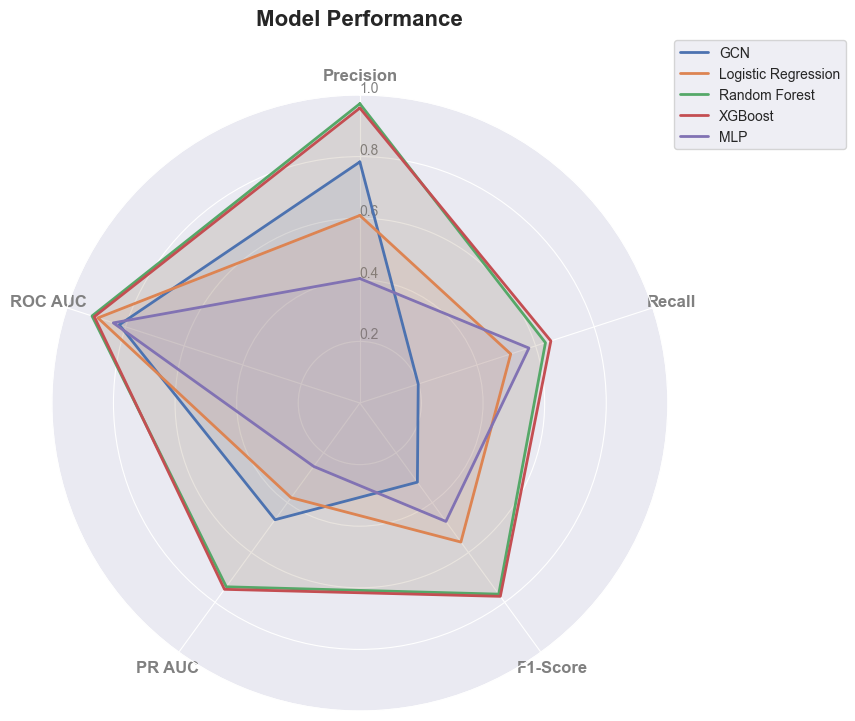

In [30]:
categories = ['Precision', 'Recall', 'F1-Score', 'PR AUC', 'ROC AUC']
N = len(categories)

df_filtered = results_df[results_df['feature_set'] == 'all']

metric_cols = ['precision_illicit', 'recall_illicit', 'f1_illicit', 'pr_auc', 'roc_auc']

models_data = {}
for index, row in df_filtered.iterrows():
    models_data[row['model']] = row[metric_cols].tolist()

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], categories, color='grey', size=12, fontweight='bold')
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.0)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

for (model_name, data), color in zip(models_data.items(), colors):
    values = data + data[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=color)
    ax.fill(angles, values, color=color, alpha=0.1)

plt.title('Model Performance', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

## XAI

### Poor performance on test dataset due to concept drift

In [31]:
def plot_f1_over_time(probs_list, model_names, x_df, y_true, thresholds):
    plt.figure(figsize=(14, 6))
    colors = sns.color_palette("tab10", len(probs_list))

    for probs, model_name, threshold, color in zip(
        probs_list, model_names, thresholds, colors
    ):
        preds = (probs >= threshold).astype(int)

        temp_df = pd.DataFrame({
            'time_step': x_df['time_step'].values,
            'y_true': y_true.values if hasattr(y_true, 'values') else y_true,
            'y_pred': preds
        })

        timesteps = sorted(temp_df['time_step'].unique())
        f1_scores = []

        for ts in timesteps:
            ts_data = temp_df[temp_df['time_step'] == ts]

            if ts_data['y_true'].sum() == 0:
                f1_scores.append(np.nan)
            else:
                f1_scores.append(
                    f1_score(
                        ts_data['y_true'],
                        ts_data['y_pred'],
                        zero_division=0
                    )
                )

        sns.lineplot(
            x=timesteps,
            y=f1_scores,
            marker='o',
            linewidth=2,
            color=color,
            label=model_name
        )

    plt.axvline(
        x=43,
        color='black',
        linestyle='--',
        alpha=0.7,
        label='AlphaBay takedown'
    )

    plt.title('F1 Score Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('F1 Score (Illicit)', fontsize=12)
    plt.ylim(-0.05, 1.05)

    plt.xticks(timesteps, rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

C:\Users\pansm\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


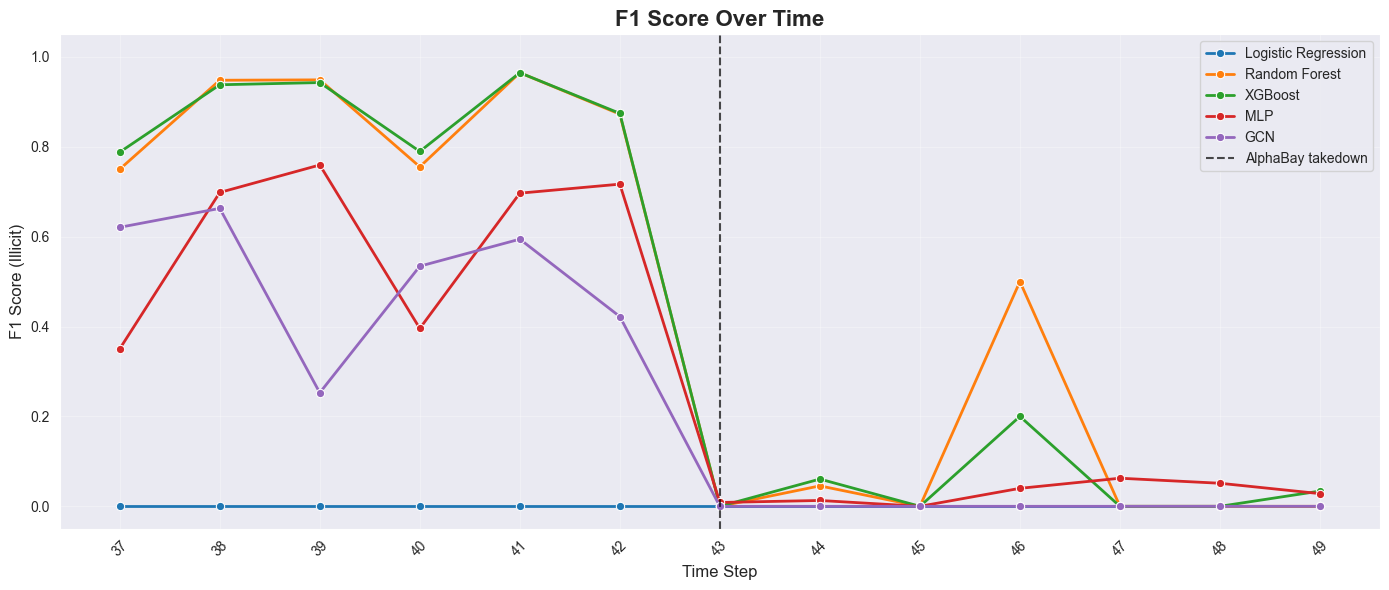

In [32]:
probs_lr = lr_all_model.predict_proba(x_all_test)[:, 1]
probs_rf = rf_all_model.predict_proba(x_all_test)[:, 1]
probs_xgb = xgb_all_model.predict_proba(x_all_test)[:, 1]
probs_mlp = mlp_all_model.predict_proba(x_all_test)[:, 1]

gcn_all_model.eval()
with torch.no_grad():
    logits, _ = gcn_all_model(graph_data.x, graph_data.edge_index)

    all_gcn_probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    probs_gcn = all_gcn_probs[test_mask.cpu().numpy()]

all_probs = [probs_lr, probs_rf, probs_xgb, probs_mlp, probs_gcn]

plot_f1_over_time(
    probs_list=all_probs,
    model_names=['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP', 'GCN'],
    x_df=x_all_test,
    y_true=y_all_test,
    thresholds=[0.54, 0.68, 0.78, 0.59, 0.76]
)

### Feature analysis

C:\Users\pansm\AppData\Local\Temp\ipykernel_15508\3968348861.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)


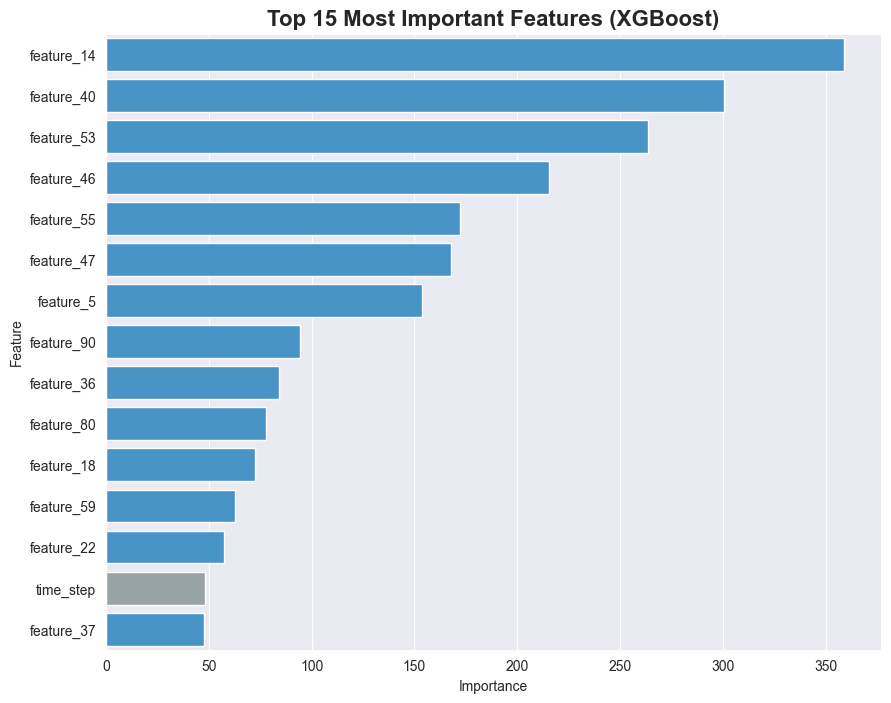

In [33]:
def plot_top_features(model, x_train, top_n=15):
    booster = model.get_booster()
    feature_names = booster.feature_names
    importances = booster.get_score(importance_type='gain')

    importance_list = [importances.get(f, 0) for f in feature_names]

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_list
    })

    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)

    colors = []
    for feat in importance_df['Feature']:
        if 'time_step' in feat:
             colors.append('#95a5a6')
        else:
            try:
                feat_num = int(feat.split('_')[1])
                colors.append('#3498db' if feat_num <= 93 else '#e67e22')
            except:
                colors.append('#3498db')

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)
    plt.title(f'Top {top_n} Most Important Features (XGBoost)', fontsize=16, fontweight='bold')
    plt.show()

plot_top_features(xgboost_model, x_all_train)

C:\Users\pansm\AppData\Local\Temp\ipykernel_15508\686026935.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)


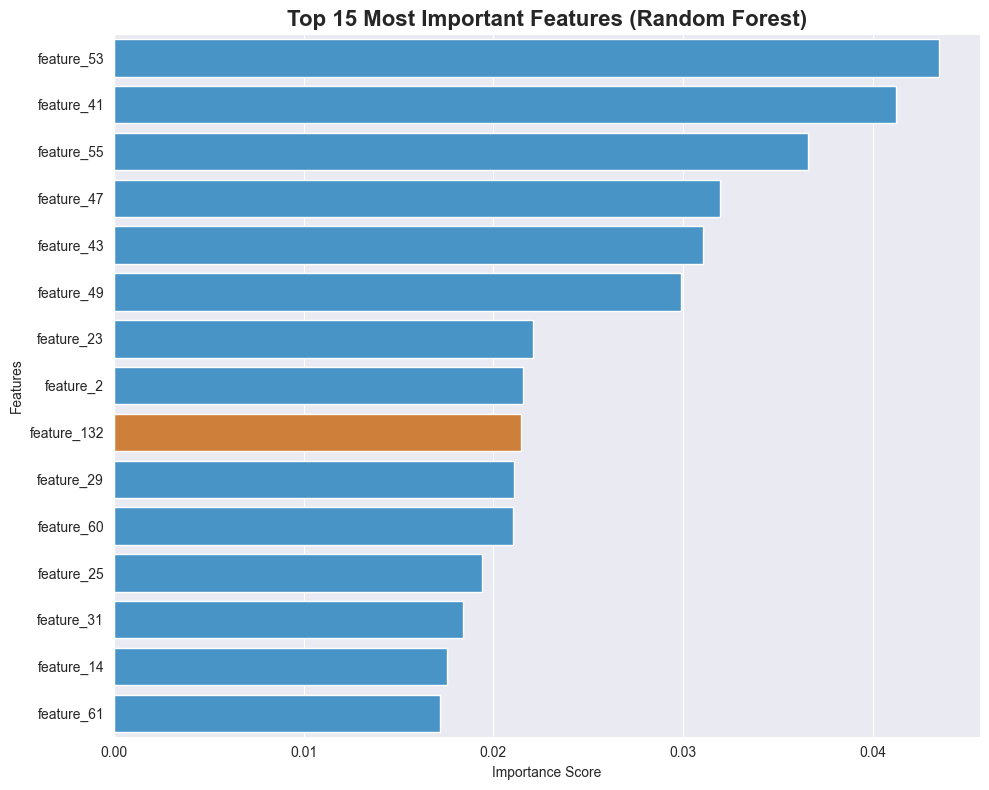

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_features_rf(model, x_train, top_n=15):
    importances = model.feature_importances_
    feature_names = x_train.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n)

    colors = []
    for feat in importance_df['Feature']:
        if 'time_step' in feat:
             colors.append('#95a5a6')
        else:
            try:
                feat_num = int(feat.split('_')[1])
                colors.append('#3498db' if feat_num <= 93 else '#e67e22')
            except:
                colors.append('#3498db')

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette=colors)
    plt.title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

plot_top_features_rf(rf_all_model, x_all_train)

C:\Users\pansm\AppData\Local\Temp\ipykernel_15508\249731351.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


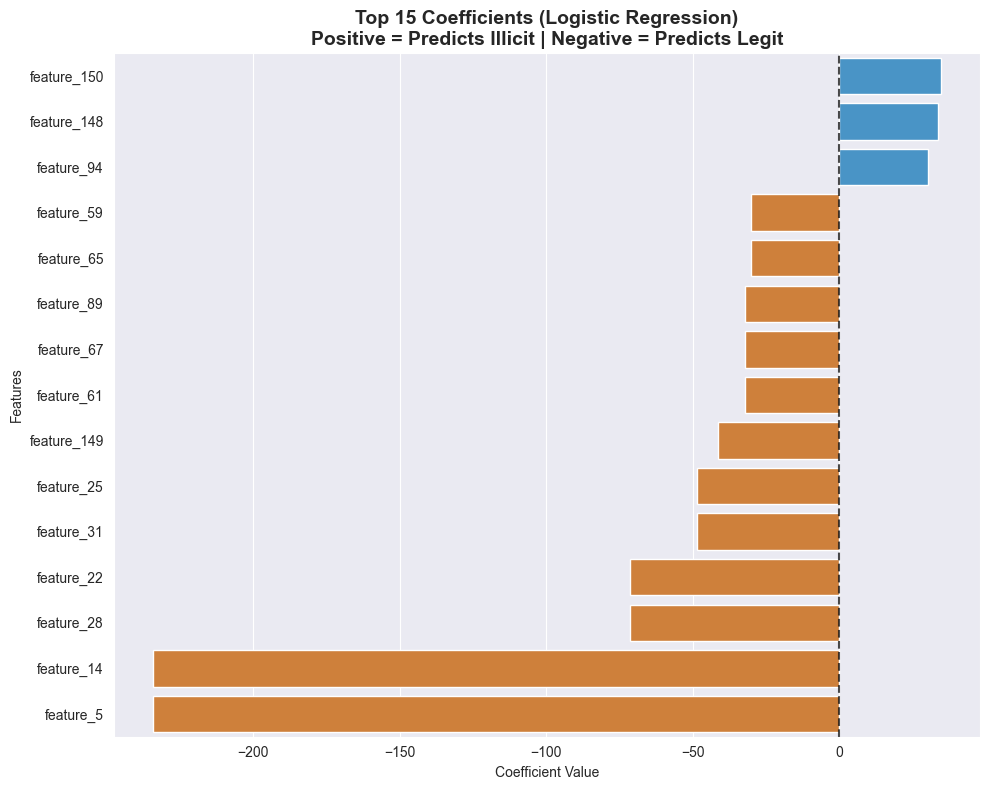

In [35]:
import numpy as np

def plot_top_features_lr(model, x_train, top_n=15):
    coefficients = model.coef_[0]
    feature_names = x_train.columns

    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    })

    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(top_n)

    coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

    colors = ['#3498db' if c > 0 else '#e67e22' for c in coef_df['Coefficient']]

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

    plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)

    plt.title(f'Top {top_n} Coefficients (Logistic Regression)\nPositive = Predicts Illicit | Negative = Predicts Legit',
              fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

plot_top_features_lr(lr_all_model, x_all_train)

## Training on 'all' features with sliding window technique

In [36]:
import torch
import numpy as np
from sklearn.metrics import f1_score

def run_gcn_rolling_evaluation(graph_data, node_time_steps, start_test_step=35, max_step=49, window_size=12, val_size=2):
    gcn_rolling_results = []
    evaluated_steps = []

    time_tensor = torch.tensor(node_time_steps)

    for target_step in range(start_test_step, max_step + 1):
        window_start = target_step - window_size
        train_end = target_step - val_size - 1
        val_start = target_step - val_size
        val_end = target_step - 1

        train_mask = (time_tensor >= window_start) & (time_tensor <= train_end)
        val_mask = (time_tensor >= val_start) & (time_tensor <= val_end)
        test_mask = (time_tensor == target_step)

        if not test_mask.any() or graph_data.y[test_mask].sum() == 0:
            continue

        evaluated_steps.append(target_step)
        print(f"GCN Simulating Step {target_step:02d} | Train: {window_start}-{train_end} | Val: {val_start}-{val_end}")

        model = build_gcn(in_features=94, hidden_size=100)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([0.7 / 0.3]).to(model.device))


        model.train()
        for epoch in range(150):
            optimizer.zero_grad()
            out, _ = model(graph_data.x, graph_data.edge_index)
            loss = criterion(out[train_mask].squeeze(), graph_data.y[train_mask].float())
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits, _ = model(graph_data.x, graph_data.edge_index)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()

        val_probs = probs[val_mask.cpu().numpy()]
        y_val_true = graph_data.y[val_mask].cpu().numpy()

        best_threshold = 0.5
        best_val_f1 = -1
        for th in np.linspace(0.1, 0.9, 17):
            v_f1 = f1_score(y_val_true, (val_probs >= th).astype(int), zero_division=0)
            if v_f1 > best_val_f1:
                best_val_f1 = v_f1
                best_threshold = th

        test_probs = probs[test_mask.cpu().numpy()]
        y_test_true = graph_data.y[test_mask].cpu().numpy()
        test_preds = (test_probs >= best_threshold).astype(int)

        step_f1 = f1_score(y_test_true, test_preds, zero_division=0)
        gcn_rolling_results.append(step_f1)

    return evaluated_steps, gcn_rolling_results

Simulating Step 35 | Train Steps: 23-32 | Val Steps: 33-34
PyTorch MLP Epoch 50/200 | Train Loss: 0.0389
PyTorch MLP Epoch 100/200 | Train Loss: 0.0198
PyTorch MLP Epoch 150/200 | Train Loss: 0.0117
PyTorch MLP Epoch 200/200 | Train Loss: 0.0071
Simulating Step 36 | Train Steps: 24-33 | Val Steps: 34-35
PyTorch MLP Epoch 50/200 | Train Loss: 0.0375
PyTorch MLP Epoch 100/200 | Train Loss: 0.0192
PyTorch MLP Epoch 150/200 | Train Loss: 0.0109
PyTorch MLP Epoch 200/200 | Train Loss: 0.0068
Simulating Step 37 | Train Steps: 25-34 | Val Steps: 35-36
PyTorch MLP Epoch 50/200 | Train Loss: 0.0324
PyTorch MLP Epoch 100/200 | Train Loss: 0.0172
PyTorch MLP Epoch 150/200 | Train Loss: 0.0094
PyTorch MLP Epoch 200/200 | Train Loss: 0.0062
Simulating Step 38 | Train Steps: 26-35 | Val Steps: 36-37
PyTorch MLP Epoch 50/200 | Train Loss: 0.0293
PyTorch MLP Epoch 100/200 | Train Loss: 0.0143
PyTorch MLP Epoch 150/200 | Train Loss: 0.0080
PyTorch MLP Epoch 200/200 | Train Loss: 0.0051
Simulating Step 

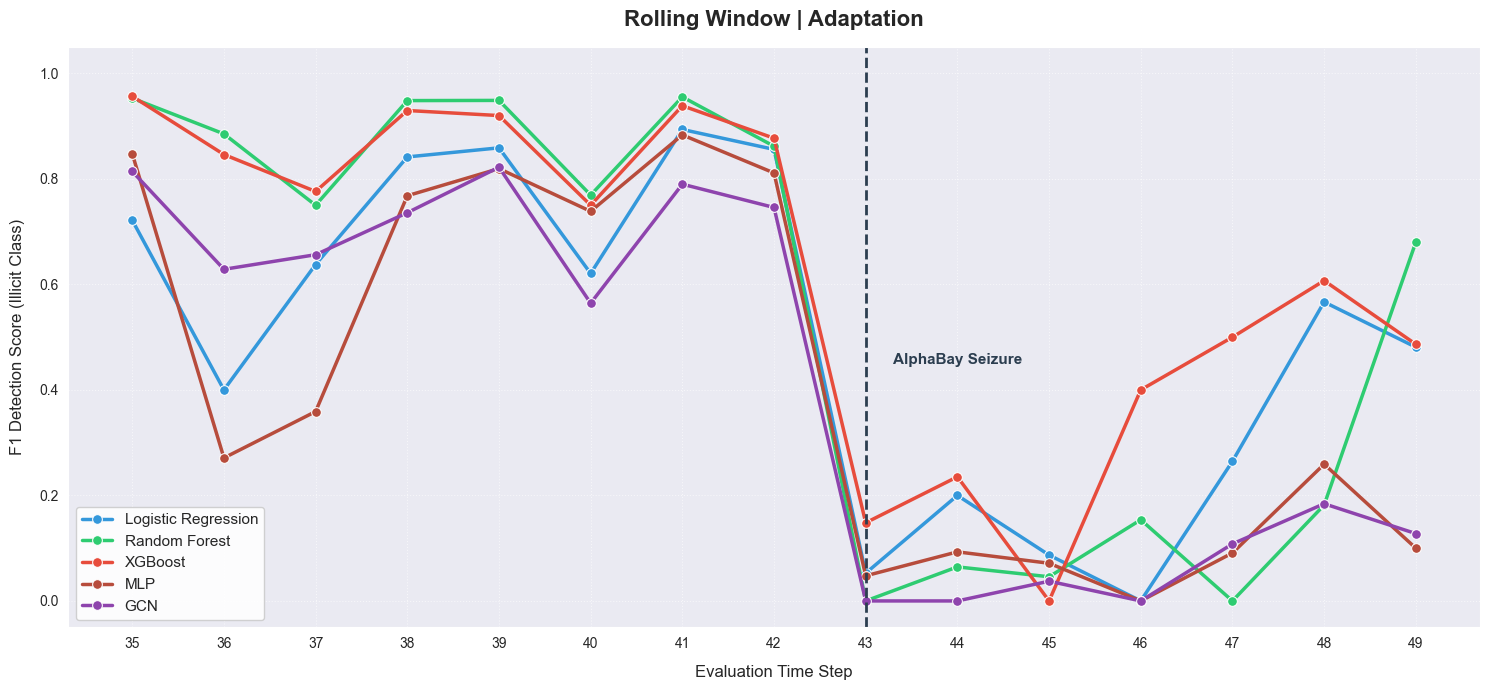

In [37]:
def run_multi_model_rolling_evaluation(splits, models_dict, window_size=10, val_size=2, start_test_step=35, max_step=49):
    x_tr, y_tr = extract_xy(splits.train, feature_set="all")
    x_va, y_va = extract_xy(splits.validation, feature_set="all")
    x_te, y_te = extract_xy(splits.test, feature_set="all")

    X_full = pd.concat([x_tr, x_va, x_te], axis=0).reset_index(drop=True)
    y_full = pd.concat([y_tr, y_va, y_te], axis=0).reset_index(drop=True)

    rolling_results = {model_name: [] for model_name in models_dict.keys()}
    evaluated_steps = []

    for target_step in range(start_test_step, max_step + 1):
        window_start = target_step - window_size
        train_end = target_step - val_size - 1
        val_start = target_step - val_size
        val_end = target_step - 1

        train_mask = (X_full['time_step'] >= window_start) & (X_full['time_step'] <= train_end)
        val_mask = (X_full['time_step'] >= val_start) & (X_full['time_step'] <= val_end)
        test_mask = (X_full['time_step'] == target_step)

        if not test_mask.any() or y_full[test_mask].sum() == 0:
            continue

        evaluated_steps.append(target_step)

        X_train_w = X_full[train_mask].drop(columns=['time_step'])
        y_train_w = y_full[train_mask]

        X_val_w = X_full[val_mask].drop(columns=['time_step'])
        y_val_w = y_full[val_mask]

        X_test_w = X_full[test_mask].drop(columns=['time_step'])
        y_test_w = y_full[test_mask]

        print(f"Simulating Step {target_step:02d} | Train Steps: {window_start}-{train_end} | Val Steps: {val_start}-{val_end}")

        for model_name, model_init_func in models_dict.items():
            model = model_init_func()

            if model_name == "Logistic Regression":
                scaler_w = StandardScaler()
                X_train_processed = scaler_w.fit_transform(X_train_w)
                X_val_processed = scaler_w.transform(X_val_w)
                X_test_processed = scaler_w.transform(X_test_w)
            else:
                X_train_processed = X_train_w
                X_val_processed = X_val_w
                X_test_processed = X_test_w

            model.fit(X_train_processed, y_train_w)

            val_probs = model.predict_proba(X_processed_val := X_val_processed)[:, 1]
            best_threshold = 0.5
            best_val_f1 = -1

            for th in np.linspace(0.1, 0.9, 17):
                v_f1 = f1_score(y_val_w, (val_probs >= th).astype(int), pos_label=1, zero_division=0)
                if v_f1 > best_val_f1:
                    best_val_f1 = v_f1
                    best_threshold = th

            test_probs = model.predict_proba(X_test_processed)[:, 1]
            test_preds = (test_probs >= best_threshold).astype(int)

            step_f1 = f1_score(y_test_w, test_preds, pos_label=1, zero_division=0)
            rolling_results[model_name].append(step_f1)

    return evaluated_steps, rolling_results


configured_models = {
    "Logistic Regression": lambda: build_logistic_regression(
        solver='lbfgs', penalty='l2', C=9642.769, class_weight=None, max_iter=1500
    ),
    "Random Forest": lambda: build_random_forest(
        n_estimators=500, max_depth=None, min_samples_split=20, min_samples_leaf=11,
        max_features='log2', class_weight='balanced_subsample'
    ),
    "XGBoost": lambda: build_xgboost(
        learning_rate=0.13619, n_estimators=300, max_depth=7, min_child_weight=2,
        gamma=1.6113, subsample=0.5656, colsample_bytree=0.5760,
        reg_alpha=9.76e-06, reg_lambda=1.21e-06, scale_pos_weight=scale_pos_weight
    ),
    "MLP": lambda: build_mlp(165, 50)
}

steps, metrics_series = run_multi_model_rolling_evaluation(
    splits=splits,
    models_dict=configured_models,
    window_size=12,
    val_size=2
)

node_time_steps = pd.concat([
    splits.train["time_step"],
    splits.validation["time_step"],
    splits.test["time_step"]
]).values

gcn_steps, gcn_scores = run_gcn_rolling_evaluation(graph_data, node_time_steps)

metrics_series["GCN"] = gcn_scores

plt.figure(figsize=(15, 7))
palette = {"Logistic Regression": "#3498db", "Random Forest": "#2ecc71", "XGBoost": "#e74c3c", "MLP": "#b74c3c"}
palette["GCN"] = "#8e44ad"

for model_name, score_list in metrics_series.items():
    sns.lineplot(
        x=steps, y=score_list, marker='o', label=model_name,
        color=palette[model_name], linewidth=2.5, markersize=7
    )

plt.axvline(x=43, color='#2c3e50', linestyle='--', linewidth=2)
plt.text(43.3, 0.45, 'AlphaBay Seizure', color='#2c3e50', weight='bold', fontsize=11)

plt.title('Rolling Window | Adaptation', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Evaluation Time Step', fontsize=12, labelpad=10)
plt.ylabel('F1 Detection Score (Illicit Class)', fontsize=12, labelpad=10)
plt.xticks(steps)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()